# Australian car affordability, 2014-2025

How many weeks of pay does a new car cost an Australian worker, how has that moved since 2014,
and where in the market does the burden fall?

This notebook runs end to end on the tables built by `make data` and `make tables`. Every
figure is produced by `carafford.figures`, so the README and this notebook show identical charts.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from carafford import figures as F
from carafford.paths import CLEAN

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
T = F.table

## 1. Why the original question had to change

The coursework version of this project treated the listing `Year` column as the year a price
was observed. It is the model year of a car listed for sale in 2023, and 90% of listings are used.
Price by `Year` therefore traced depreciation, not price change. Mileage by model year makes that
plain:

In [2]:
cars = pd.read_csv(CLEAN.parent / "interim" / "listings_clean.csv")
by_year = cars[cars["year"] >= 2014].groupby("year").agg(
    listings=("price", "size"), used_share=("condition", lambda s: (s == "Used").mean()),
    median_km=("km", "median"), median_price=("price", "median"))
by_year

,listings,used_share,median_km,median_price
year,,,,
2014,864,1.00,"129,344.00","19,990.00"
2015,1070,1.00,"116,341.00","23,999.00"
2016,1112,1.00,"104,090.00","27,992.50"
2017,1336,1.00,"90,223.50","29,990.00"
2018,1574,1.00,"78,081.50","33,769.50"
2019,1459,1.00,"61,459.00","35,990.00"
2020,1114,1.00,"50,680.00","35,984.00"
2021,1084,0.99,"29,236.00","39,990.00"
2022,1292,0.57,"4,100.00","49,990.00"


The rebuild separates the two questions the data can actually answer:

- **Change over time** comes from the ABS motor vehicles price index (quality adjusted, quarterly).
- **Market structure** (segments, brands, states, depreciation) comes from the 2023 listings cross-section.

The two meet at one point: the median 2023 new or demo listing price anchors the index in dollars.

## 2. Wrangling audit

In [3]:
T_log = pd.read_csv(CLEAN / "listings_cleaning_log.csv")
T_log

,step,rows,dropped
0,raw listings,16734,0
1,drop blank rows,16733,1
2,drop missing or POA price,16681,52
3,drop near-duplicate listings,16618,63
4,"keep price $2,000 to $400,000",16593,25
5,keep age 0 to 20 years,16333,260
6,"drop km above 500,000",16328,5
7,"drop 'new' cars with over 5,000 km",16327,1
8,drop unknown body type,16043,284


In [4]:
earn = pd.read_csv(CLEAN / "median_weekly_earnings.csv")
earn["reliability"].value_counts()

reliability
ok            2650
caution         21
unreliable       2
Name: count, dtype: int64

Two earnings cells carry an ABS relative standard error above 50% and are flagged unreliable.
Neither feeds a headline number; the national group medians used below all have RSEs of 3.4% or less.

## 3. Affordability over time

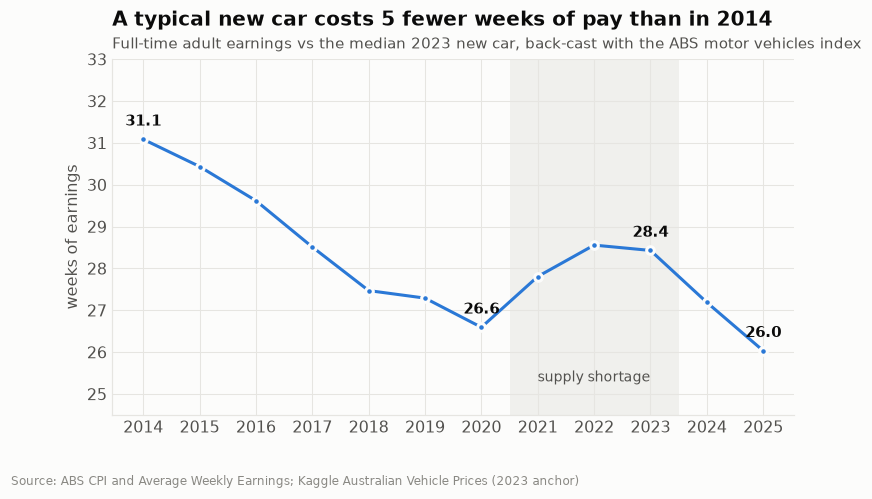

In [5]:
F.weeks_to_buy();

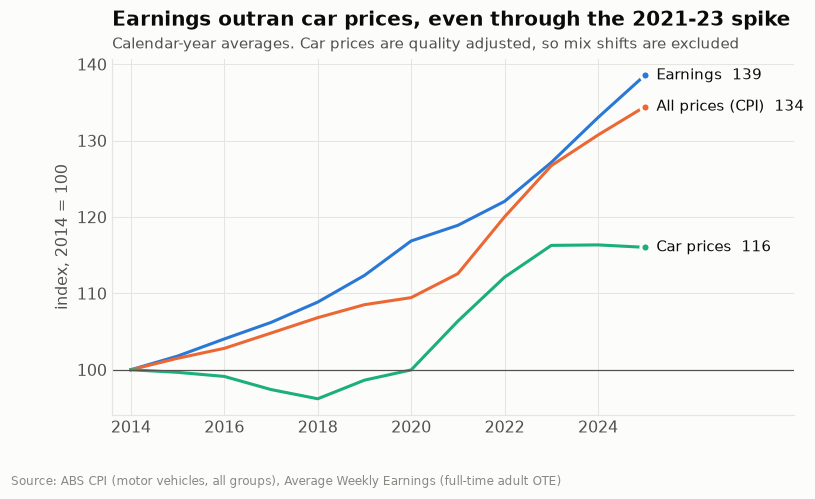

In [6]:
F.indexed_growth();

Car prices (quality adjusted) rose 16% from 2014 to 2025 while full-time earnings rose 39%.
The 2021-23 supply shortage pushed car prices up 16% in three years, but earnings growth absorbed
it: the typical new car fell from 31.1 weeks of full-time pay in 2014 to 26.0 in 2025.

In [7]:
w = T("weeks_by_awe")
w[(w["sex"] == "Persons") & w["year"].isin([2014, 2025])].pivot(index="region", columns="year", values="weeks")

year,2014,2025
region,,
ACT,27.07,23.60
AUS,31.09,26.03
NSW,30.87,25.56
NT,31.74,27.32
QLD,31.47,26.78
SA,33.68,27.61
TAS,36.25,29.25
VIC,32.82,26.61
WA,27.49,24.32


## 4. Who carries the burden

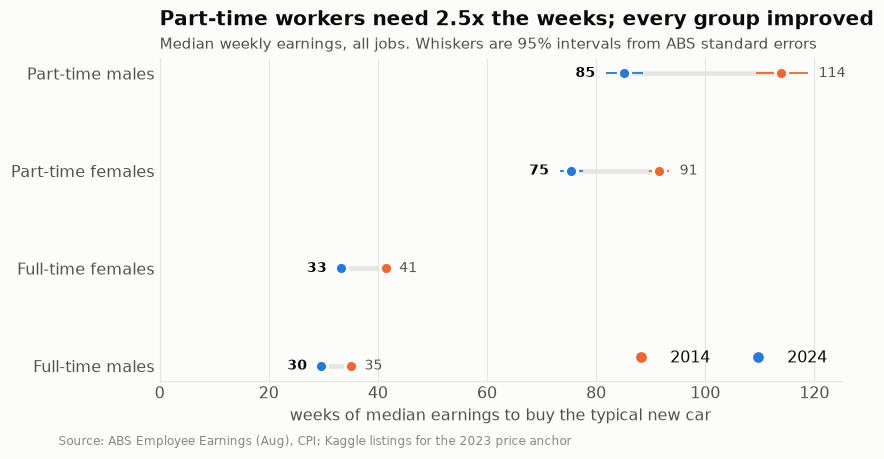

In [8]:
F.group_weeks();

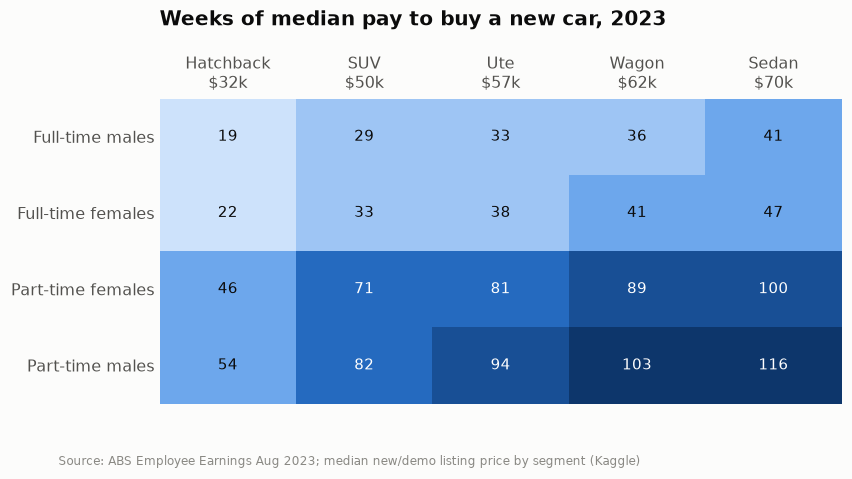

In [9]:
F.group_segment_heatmap();

Every group needs fewer weeks than in 2014, but the spread between groups dwarfs the change over
time. A part-time worker needs about 2.5 times the weeks of a full-time worker of the same sex. Part-time
men, not part-time women, sit at the bottom, with lower median weekly earnings ( vs  in 2024).
Full-time women need 12-13% more weeks than full-time men.

## 5. Where prices differ: state premiums with the mix held fixed

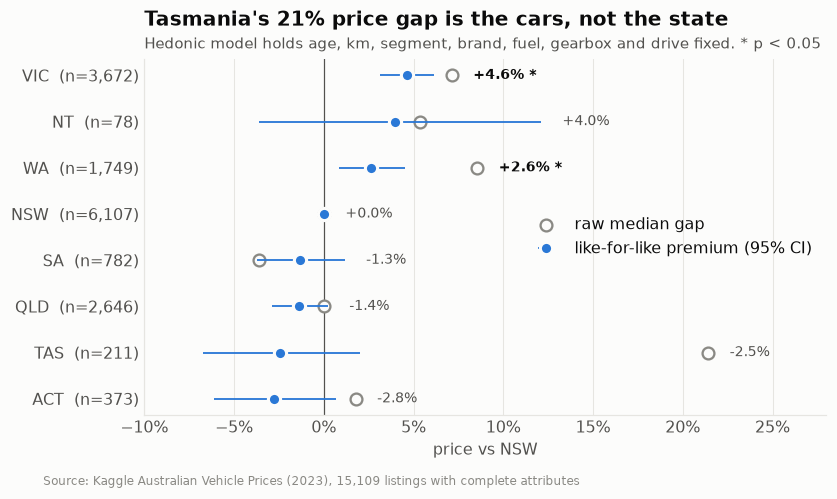

In [10]:
F.state_premiums();

In [11]:
T("state_premiums")

,state,adjusted_pct,ci_lo,ci_hi,p_value,raw_median,n,raw_pct
0,VIC,4.62,3.15,6.12,0.00,"29,990.00",3672,7.13
1,NT,3.95,-3.60,12.09,0.31,"29,490.00",78,5.34
2,WA,2.65,0.82,4.51,0.00,"30,388.00",1749,8.55
3,NSW,0.00,0.00,0.00,1.00,"27,995.00",6107,0.00
4,SA,-1.31,-3.72,1.15,0.29,"26,990.00",782,-3.59
5,QLD,-1.36,-2.91,0.22,0.09,"27,990.00",2646,-0.02
6,TAS,-2.45,-6.72,2.01,0.28,"33,990.00",211,21.41
7,ACT,-2.80,-6.15,0.67,0.11,"28,490.00",373,1.77


Raw medians suggest Tasmania is 21% dearer than NSW. Holding age, km, segment, brand, fuel,
gearbox and drive fixed, the Tasmanian premium disappears (-2.5%, CI spans zero): its listings are
simply a different mix of cars. Victoria (+4.6%) and Western Australia (+2.6%) carry real like-for-like
premiums. The Northern Territory estimate is too noisy to call with 78 listings.

## 6. Depreciation

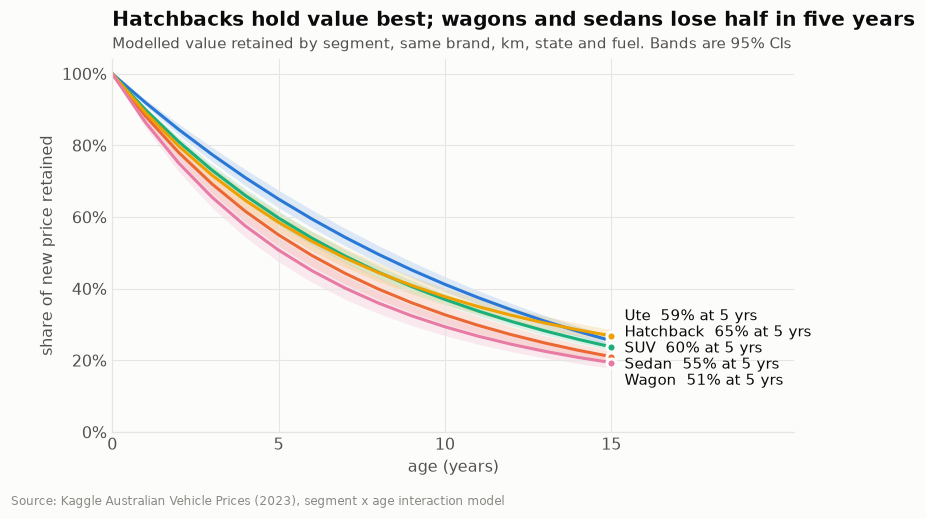

In [12]:
F.depreciation();

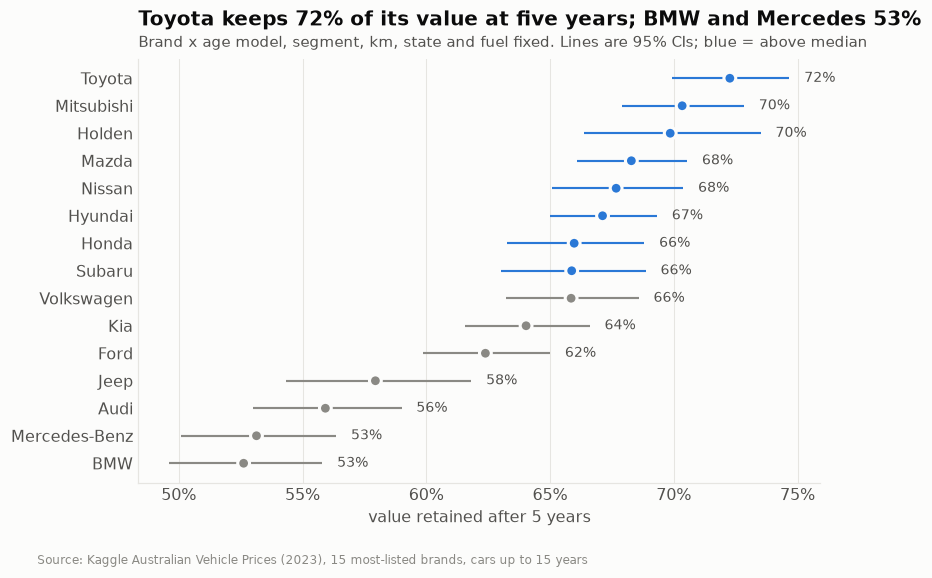

In [13]:
F.brand_retention();

Hatchbacks keep 65% of their value after five years; wagons keep 51%. Brand matters more than
segment: Toyota keeps 72% against 53% for BMW and Mercedes-Benz, with non-overlapping intervals.
For a budget-constrained buyer, the cheapest segment to buy new is also the one that holds value best.

## 7. Mix shift

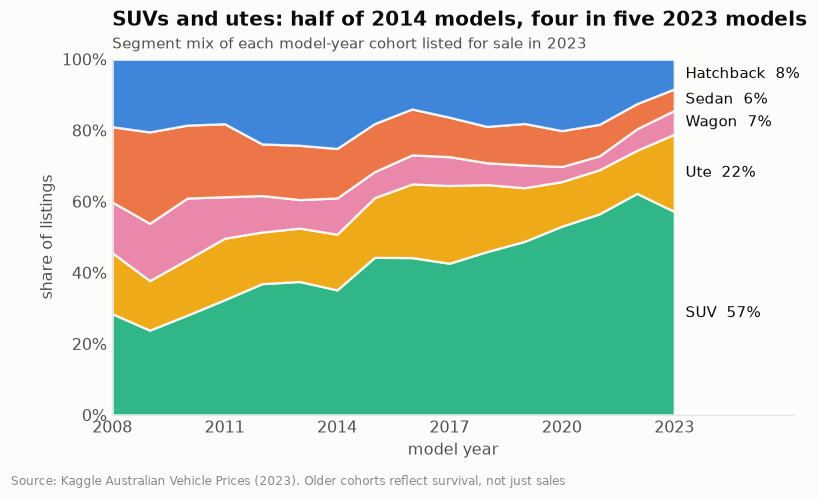

In [14]:
F.cohort_mix();

In [15]:
T("mix_shift")[["year", "suv_ute_share", "mix_price", "vs_2014"]].query("year >= 2014")

,year,suv_ute_share,mix_price,vs_2014
6,2014,0.51,"50,396.75",0.00
7,2015,0.61,"51,238.71",0.02
8,2016,0.65,"52,203.40",0.04
9,2017,0.64,"51,510.31",0.02
10,2018,0.65,"50,429.72",0.00
11,2019,0.64,"50,633.09",0.00
12,2020,0.66,"49,518.00",-0.02
13,2021,0.69,"49,523.10",-0.02
14,2022,0.74,"50,404.16",0.00
15,2023,0.79,"51,663.17",0.03


SUVs and utes rose from about half of 2014 model-year listings to 79% of 2023 models. At 2023 segment
prices this mix shift adds only 2.5% to the typical price, because the new SUVs and utes listed in 2023
are cheaper than new sedans and wagons. The real casualty is the hatchback: the one segment that is both
cheapest new and slowest to depreciate fell to 8% of 2023 models.

## 8. Model validation

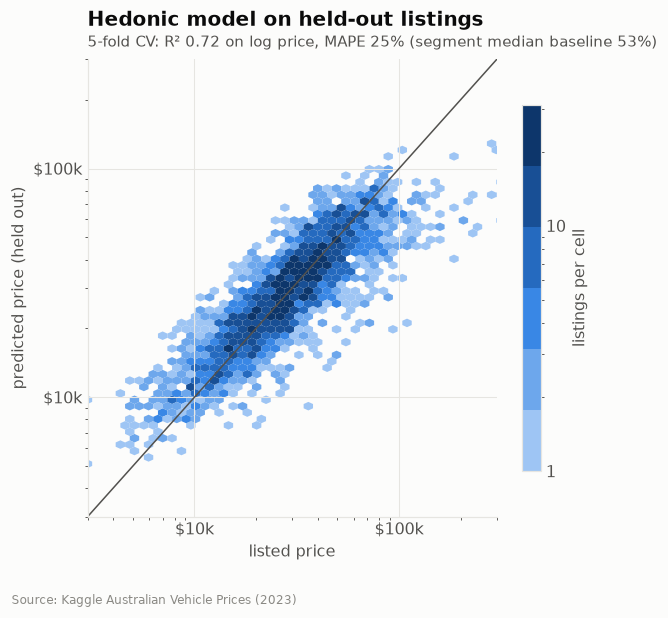

In [16]:
F.model_fit();

In [17]:
T("hedonic_cv").groupby("model")[["rmse_log", "mape", "r2_log"]].mean()

,rmse_log,mape,r2_log
model,,,
hedonic,0.34,0.25,0.72
segment median,0.60,0.53,0.10


The hedonic model explains 72% of out-of-sample variance in log price and halves the error of a
segment-median baseline (MAPE 25% vs 53%). Residual spread is widest above $100k, where trim and options
the listing does not record drive price. State and brand effects above use HC3 robust standard errors.

## 9. Limitations

- The motor vehicles index is quality adjusted. It tracks the price of a like-for-like car, not what
  buyers spend; the mix-shift section covers the difference.
- Listing prices are asking prices from one 2023 snapshot, not transaction prices.
- Cohort mix in 2023 listings reflects which cars survive and get resold, not only original sales.
- The ABS publishes the motor vehicles index nationally only, so state differences come from listings.
- Earnings exclude the self-employed and household income; a two-earner household faces a different ratio.